In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load final clean dataset
df = pd.read_parquet(r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\data\processed\bbl_final.parquet")

print(f"Shape: {df.shape}")
print(df.head())

Shape: (153250, 35)
  match_id   season start_date                      venue  innings  ball  \
0  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.1   
1  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.2   
2  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.3   
3  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.4   
4  1023581  2016/17 2016-12-20  Sydney Showground Stadium        1   0.5   

     batting_team   bowling_team       striker non_striker  ... is_four  \
0  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
1  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
2  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
3  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   
4  Sydney Thunder  Sydney Sixers  KR Patterson   RJ Gibson  ...       0   

   is_six      phase         winner    toss_winner  toss_decision  \
0  

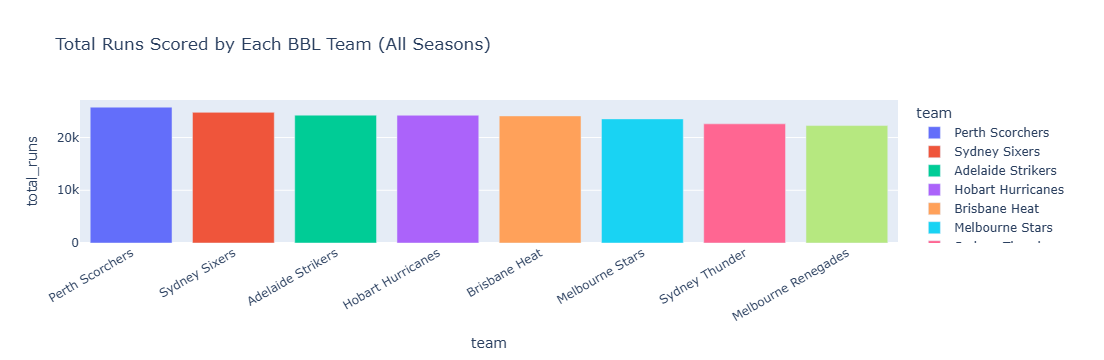

                  team  total_runs
0      Perth Scorchers       25769
1        Sydney Sixers       24781
2    Adelaide Strikers       24252
3    Hobart Hurricanes       24235
4        Brisbane Heat       24107
5      Melbourne Stars       23542
6       Sydney Thunder       22601
7  Melbourne Renegades       22273


In [2]:
# Total runs scored BY each team across all seasons
team_runs = df.groupby("batting_team")["runs_off_bat"].sum().sort_values(ascending=False).reset_index()
team_runs.columns = ["team", "total_runs"]

fig = px.bar(team_runs, x="team", y="total_runs",
             title="Total Runs Scored by Each BBL Team (All Seasons)",
             color="team")
fig.update_layout(xaxis_tickangle=-30)
fig.show()
print(team_runs)

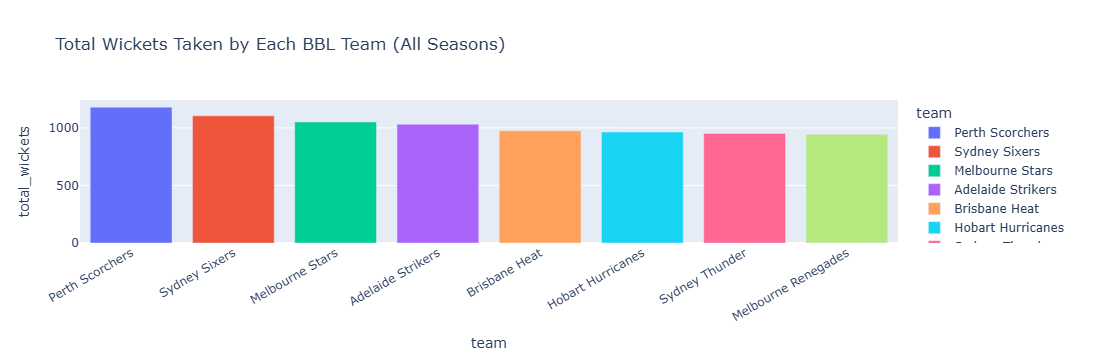

                  team  total_wickets
0      Perth Scorchers           1180
1        Sydney Sixers           1105
2      Melbourne Stars           1051
3    Adelaide Strikers           1032
4        Brisbane Heat            974
5    Hobart Hurricanes            964
6       Sydney Thunder            952
7  Melbourne Renegades            944


In [3]:
# Total wickets taken BY each team (bowling)
team_wickets = df[df["is_wicket"] == 1].groupby("bowling_team")["is_wicket"].sum().sort_values(ascending=False).reset_index()
team_wickets.columns = ["team", "total_wickets"]

fig = px.bar(team_wickets, x="team", y="total_wickets",
             title="Total Wickets Taken by Each BBL Team (All Seasons)",
             color="team")
fig.update_layout(xaxis_tickangle=-30)
fig.show()
print(team_wickets)

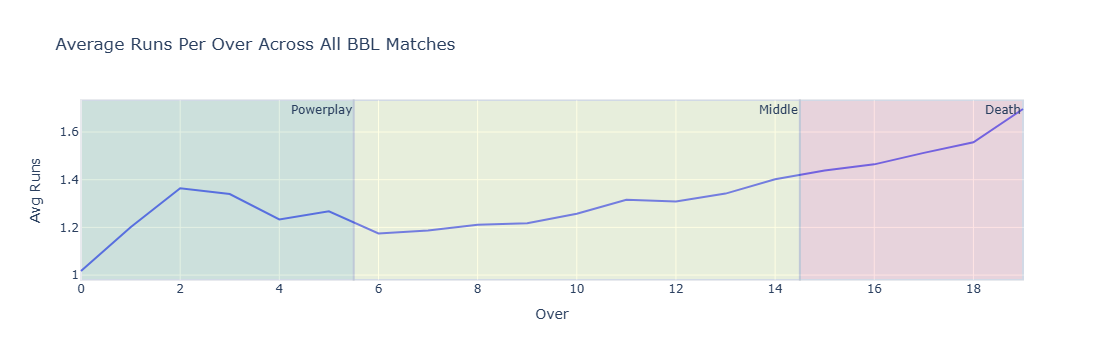

In [4]:
# Average runs per over across all matches
over_runs = df.groupby("over")["total_runs"].mean().reset_index()
over_runs.columns = ["over", "avg_runs"]

fig = px.line(over_runs, x="over", y="avg_runs",
              title="Average Runs Per Over Across All BBL Matches",
              labels={"over": "Over", "avg_runs": "Avg Runs"})

# Add phase shading so the chart tells the story visually
fig.add_vrect(x0=0,    x1=5.5,  fillcolor="green",  opacity=0.1, annotation_text="Powerplay")
fig.add_vrect(x0=5.5,  x1=14.5, fillcolor="yellow", opacity=0.1, annotation_text="Middle")
fig.add_vrect(x0=14.5, x1=19,   fillcolor="red",    opacity=0.1, annotation_text="Death")

fig.show()

       phase  total_runs  total_balls  run_rate
0      Death       48245        32016  9.041417
1     Middle       86157        68919  7.500718
2  Powerplay       57158        47324  7.246809


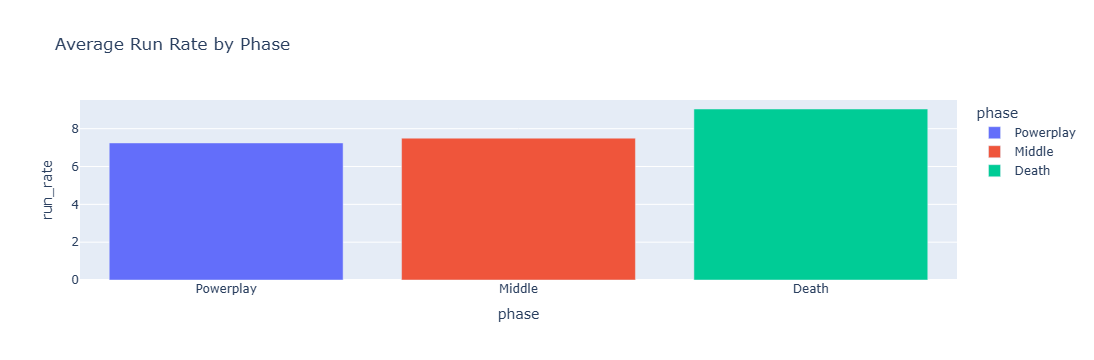

In [5]:
# Which phase produces the highest run rate?
# This will be a key insight in our dashboard
phase_runs = df.groupby("phase").agg(
    total_runs  = ("runs_off_bat", "sum"),
    total_balls = ("is_legal", "sum"),
).reset_index()

phase_runs["run_rate"] = (phase_runs["total_runs"] / phase_runs["total_balls"]) * 6

print(phase_runs)

fig = px.bar(phase_runs, x="phase", y="run_rate",
             title="Average Run Rate by Phase",
             color="phase",
             category_orders={"phase": ["Powerplay", "Middle", "Death"]})
fig.show()

In [6]:
# Build batter stats table
batter_stats = df.groupby("striker").agg(
    runs        = ("runs_off_bat", "sum"),
    balls_faced = ("is_legal", "sum"),
    dismissals  = ("is_wicket", "sum"),
    fours       = ("is_four", "sum"),
    sixes       = ("is_six", "sum"),
    innings     = ("match_id", "nunique")
).reset_index()

# Calculate key metrics
batter_stats["average"]      = (batter_stats["runs"] / batter_stats["dismissals"].replace(0, 1)).round(2)
batter_stats["strike_rate"]  = ((batter_stats["runs"] / batter_stats["balls_faced"].replace(0, 1)) * 100).round(2)
batter_stats["boundary_pct"] = (((batter_stats["fours"] + batter_stats["sixes"]) / batter_stats["balls_faced"].replace(0, 1)) * 100).round(2)

# Filter to meaningful sample — at least 20 innings
# (removes players who only played 1-2 games and have inflated stats)
batter_stats = batter_stats[batter_stats["innings"] >= 20]

print(f"Batters with 20+ innings: {len(batter_stats)}")
print(batter_stats.sort_values("runs", ascending=False).head(10))

Batters with 20+ innings: 157
          striker  runs  balls_faced  dismissals  fours  sixes  innings  \
77        CA Lynn  4088         2723         116    343    225      133   
297  MC Henriques  3356         2589         123    246    102      143   
19       AJ Finch  3310         2512          92    292    118      104   
319    MP Stoinis  3218         2394          98    286    117      114   
155    GJ Maxwell  3196         2050          95    263    149      116   
122     DJM Short  3138         2377          93    305    107      102   
64   BR McDermott  3104         2237          88    214    146      110   
323       MS Wade  2946         2070         100    250    103      111   
245      JW Wells  2935         2406          87    237     51      123   
413      SE Marsh  2802         2148          68    255     89       77   

     average  strike_rate  boundary_pct  
77     35.24       150.13         20.86  
297    27.28       129.63         13.44  
19     35.98      

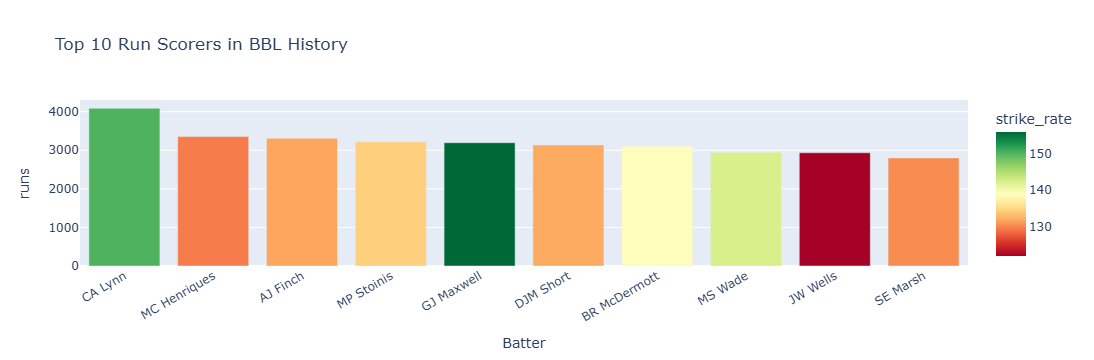

In [7]:
# Top 10 run scorers — colour coded by strike rate
# so we can see if high run scorers are also fast scorers
top_batters = batter_stats.sort_values("runs", ascending=False).head(10)

fig = px.bar(top_batters, x="striker", y="runs",
             title="Top 10 Run Scorers in BBL History",
             color="strike_rate",
             color_continuous_scale="RdYlGn",
             hover_data=["average", "strike_rate", "sixes", "fours"],
             labels={"striker": "Batter"})
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [8]:
# Strike rate vs Average scatter
# Top right = elite (high average AND high strike rate)
# The dashed lines show the median — anyone above both lines is above average
fig = px.scatter(batter_stats, x="average", y="strike_rate",
                 hover_name="striker",
                 size="runs",
                 color="sixes",
                 title="Batter Comparison — Average vs Strike Rate (bubble size = total runs)",
                 labels={"average": "Batting Average", "strike_rate": "Strike Rate"})

fig.add_hline(y=batter_stats["strike_rate"].median(), line_dash="dash", line_color="gray")
fig.add_vline(x=batter_stats["average"].median(),     line_dash="dash", line_color="gray")

fig.show()

In [9]:
# Build bowler stats table
bowler_stats = df.groupby("bowler").agg(
    balls   = ("is_legal", "sum"),
    runs    = ("runs_off_bat", "sum"),
    wickets = ("is_wicket", "sum"),
    matches = ("match_id", "nunique")
).reset_index()

bowler_stats["economy"] = ((bowler_stats["runs"] / bowler_stats["balls"].replace(0, 1)) * 6).round(2)
bowler_stats["average"] = (bowler_stats["runs"] / bowler_stats["wickets"].replace(0, 1)).round(2)
bowler_stats["sr"]      = (bowler_stats["balls"] / bowler_stats["wickets"].replace(0, 1)).round(2)

# Filter — at least 20 matches
# (removes bowlers with very few appearances whose stats aren't meaningful)
bowler_stats = bowler_stats[bowler_stats["matches"] >= 20]

print(f"Bowlers with 20+ matches: {len(bowler_stats)}")
print(bowler_stats.sort_values("wickets", ascending=False).head(10))

Bowlers with 20+ matches: 118
             bowler  balls  runs  wickets  matches  economy  average     sr
298       SA Abbott   2673  3644      196      129     8.18    18.59  13.64
15           AJ Tye   2507  3240      176      116     7.75    18.41  14.24
42     BJ Dwarshuis   2690  3502      168      126     7.81    20.85  16.01
171  JP Behrendorff   2437  2814      154      112     6.93    18.27  15.82
191   KW Richardson   2476  3197      153      113     7.75    20.90  16.18
102         DR Sams   1950  2722      139       96     8.38    19.58  14.03
274       PM Siddle   2124  2601      137      103     7.35    18.99  15.50
1           A Zampa   2575  3100      135      116     7.22    22.96  19.07
287     RP Meredith   1946  2576      123       90     7.94    20.94  15.82
148   JA Richardson   1783  2239      119       80     7.53    18.82  14.98


In [10]:
# Top 10 wicket takers — colour coded by economy
# Green = low economy (good), Red = high economy (expensive)
top_bowlers = bowler_stats.sort_values("wickets", ascending=False).head(10)

fig = px.bar(top_bowlers, x="bowler", y="wickets",
             title="Top 10 Wicket Takers in BBL History",
             color="economy",
             color_continuous_scale="RdYlGn_r",
             hover_data=["economy", "average", "matches"],
             labels={"bowler": "Bowler"})
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [11]:
# Economy vs Wickets scatter
# Best bowlers = bottom right (lots of wickets, low economy)
fig = px.scatter(bowler_stats, x="economy", y="wickets",
                 hover_name="bowler",
                 size="matches",
                 title="Bowler Comparison — Economy vs Wickets",
                 labels={"economy": "Economy Rate", "wickets": "Total Wickets"})

fig.add_vline(x=bowler_stats["economy"].median(), line_dash="dash", line_color="gray")
fig.show()

In [12]:
# Group by bowler AND phase to get phase-specific stats
phase_bowler = df.groupby(["bowler", "phase"]).agg(
    balls   = ("is_legal", "sum"),
    runs    = ("runs_off_bat", "sum"),
    wickets = ("is_wicket", "sum")
).reset_index()

phase_bowler["economy"] = ((phase_bowler["runs"] / phase_bowler["balls"].replace(0, 1)) * 6).round(2)

# Filter — at least 60 legal balls in that phase
# (removes small sample sizes that would skew the economy rate)
phase_bowler = phase_bowler[phase_bowler["balls"] >= 60]

# Best death bowlers (lowest economy in death overs)
death_bowlers = phase_bowler[phase_bowler["phase"] == "Death"].sort_values("economy").head(10)
print("Best Death Bowlers (Economy):")
print(death_bowlers[["bowler", "balls", "wickets", "economy"]])

# Best powerplay bowlers
pp_bowlers = phase_bowler[phase_bowler["phase"] == "Powerplay"].sort_values("economy").head(10)
print("\nBest Powerplay Bowlers (Economy):")
print(pp_bowlers[["bowler", "balls", "wickets", "economy"]])

Best Death Bowlers (Economy):
               bowler  balls  wickets  economy
817        SL Malinga     90        5     5.80
299           GB Hogg    186       21     6.16
652     Mohammad Nabi     71        6     6.42
969        XJ Doherty     72        9     6.58
655  Mujeeb Ur Rahman    138       13     6.74
574    M Muralitharan     66        2     6.82
8             AC Agar    230       20     6.83
857       Shadab Khan     66        4     6.91
698    Naved-ul-Hasan     89       12     6.94
582           MA Beer    125        8     7.01

Best Powerplay Bowlers (Economy):
             bowler  balls  wickets  economy
938  Usman Shinwari     84        4     4.71
598      MG Johnson    234       13     4.97
465        JR Hopes    150        6     5.12
819      SL Malinga     84        3     5.21
304      GD Putland     60        1     5.30
541     LH Ferguson     60        3     5.30
250      DL Vettori     90        2     5.40
974    Yasir Arafat     88        7     5.52
81           

In [13]:
# Get one row per match with toss and winner info
toss_df = df.drop_duplicates("match_id")[["match_id", "winner", "toss_winner", "toss_decision"]].dropna()

# Did the toss winner also win the match?
toss_df["toss_helped"] = (toss_df["winner"] == toss_df["toss_winner"])

print("Did winning the toss lead to winning the match?")
print(toss_df["toss_helped"].value_counts(normalize=True).round(3) * 100)

fig = px.pie(toss_df, names="toss_helped",
             title="Toss Winner = Match Winner? (True/False)",
             color_discrete_map={True: "green", False: "salmon"})
fig.show()

Did winning the toss lead to winning the match?
toss_helped
True     53.0
False    47.0
Name: proportion, dtype: float64


  decision  win_rate
0      bat      50.4
1    field      54.6


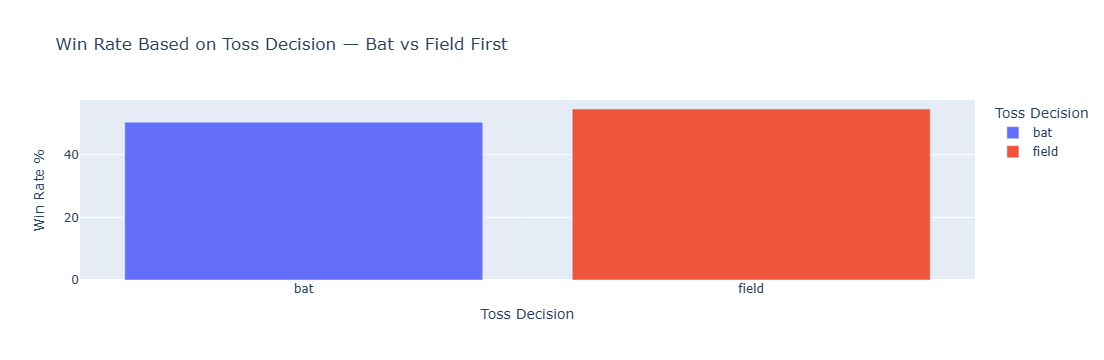

In [14]:
# Does the decision (bat or field) matter more than just winning the toss?
decision_wins = toss_df.groupby("toss_decision")["toss_helped"].mean().reset_index()
decision_wins.columns = ["decision", "win_rate"]
decision_wins["win_rate"] = (decision_wins["win_rate"] * 100).round(1)

print(decision_wins)

fig = px.bar(decision_wins, x="decision", y="win_rate",
             title="Win Rate Based on Toss Decision — Bat vs Field First",
             labels={"decision": "Toss Decision", "win_rate": "Win Rate %"},
             color="decision")
fig.show()

     season  matches  runs_per_match  sixes_per_match
0   2011/12       27           289.3              9.8
1   2012/13       28           262.9              8.6
2   2013/14       34           277.4              9.0
3   2014/15       34           281.1              9.2
4   2015/16       32           302.2             11.0
5   2016/17       35           305.0             11.0
6   2017/18       43           298.1             10.8
7   2018/19       59           278.6              8.9
8   2019/20       61           278.8              9.9
9   2020/21       61           295.8             10.5
10  2021/22       60           295.6              9.9
11  2022/23       61           284.5              9.8
12  2023/24       41           287.2             10.7
13  2024/25       42           305.5             12.1
14  2025/26       44           296.5             12.5


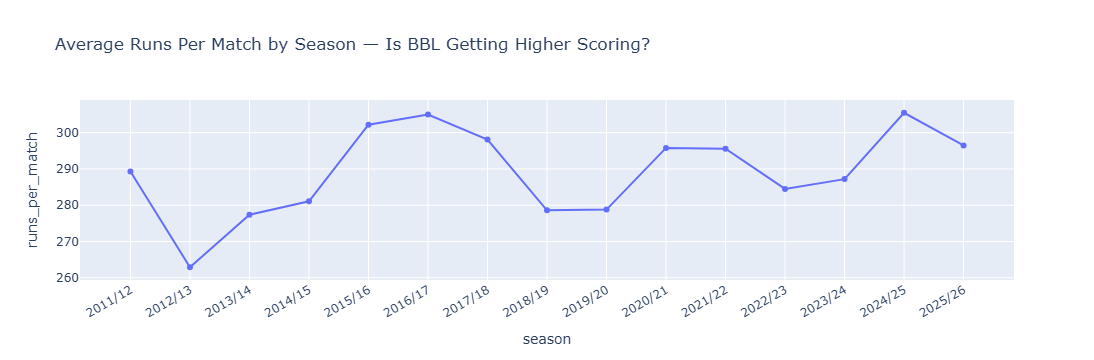

In [15]:
# Aggregate stats per season
season_stats = df.groupby("season").agg(
    total_runs    = ("runs_off_bat", "sum"),
    total_sixes   = ("is_six", "sum"),
    total_fours   = ("is_four", "sum"),
    total_wickets = ("is_wicket", "sum"),
    matches       = ("match_id", "nunique")
).reset_index()

# Per-match averages to account for different number of matches per season
season_stats["runs_per_match"]   = (season_stats["total_runs"]  / season_stats["matches"]).round(1)
season_stats["sixes_per_match"]  = (season_stats["total_sixes"] / season_stats["matches"]).round(1)
season_stats["fours_per_match"]  = (season_stats["total_fours"] / season_stats["matches"]).round(1)

print(season_stats[["season", "matches", "runs_per_match", "sixes_per_match"]])

# Is BBL scoring more runs per match over time?
fig = px.line(season_stats, x="season", y="runs_per_match",
              title="Average Runs Per Match by Season — Is BBL Getting Higher Scoring?",
              markers=True)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

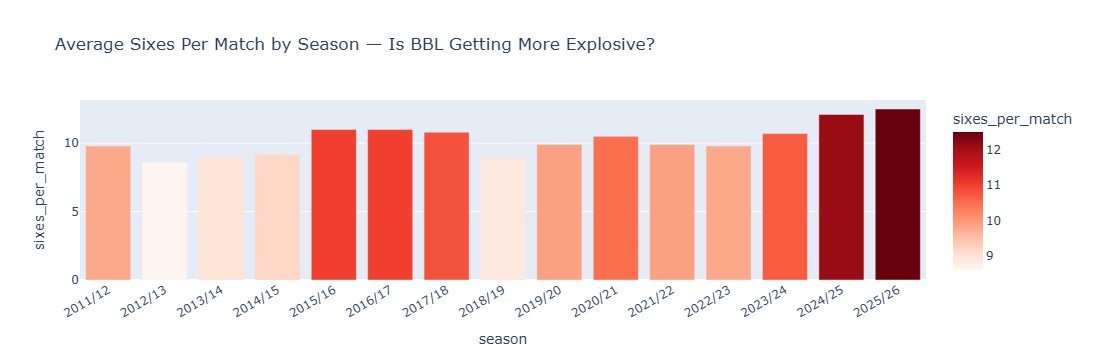

In [16]:
# Are batters hitting more sixes over time?
# This is one of the most visually satisfying charts
fig = px.bar(season_stats, x="season", y="sixes_per_match",
             title="Average Sixes Per Match by Season — Is BBL Getting More Explosive?",
             color="sixes_per_match",
             color_continuous_scale="Reds")
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [17]:
import os

processed = r"C:\Users\HP\OneDrive\Desktop\bbl-cricket-dashboard\data\processed"

batter_stats.to_parquet(os.path.join(processed, "batter_stats.parquet"),      index=False)
bowler_stats.to_parquet(os.path.join(processed, "bowler_stats.parquet"),      index=False)
season_stats.to_parquet(os.path.join(processed, "season_stats.parquet"),      index=False)
phase_bowler.to_parquet(os.path.join(processed, "phase_bowler_stats.parquet"),index=False)

print("✅ All stats tables saved!")

✅ All stats tables saved!
